<a href="https://colab.research.google.com/github/gmahathi/ComputerVision/blob/main/Part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Handwritten English Character Recognition Using Classical Vision & Machine Learning**

In [1]:
# Cell 1: imports
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import cv2
from PIL import Image
import pandas as pd

# ML / util
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Torchvision for EMNIST dataset (will download if not present)
import torchvision
from torchvision import transforms, datasets

# Reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


In [2]:
# Load EMNIST Letters via torchvision
data_root = "./data_emnist"

transform_raw = transforms.Compose([
    transforms.ToTensor()  # keep as tensor for now (C,H,W) with values [0,1]
])

emnist_train = datasets.EMNIST(root=data_root, split='letters', train=True,
                              download=True, transform=transform_raw)
emnist_test  = datasets.EMNIST(root=data_root, split='letters', train=False,
                              download=True, transform=transform_raw)

print(f"EMNIST train size: {len(emnist_train)}")
print(f"EMNIST test  size: {len(emnist_test)}")


100%|██████████| 562M/562M [00:11<00:00, 50.4MB/s]


EMNIST train size: 124800
EMNIST test  size: 20800


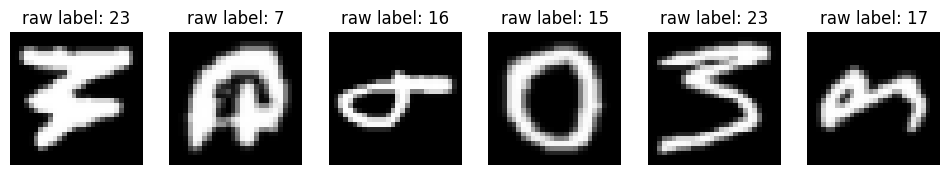

In [3]:
# Visualize a few raw samples so we can check orientation and label mapping
def show_emnist_samples(dataset, n=6):
    fig, axs = plt.subplots(1, n, figsize=(12,3))
    for i in range(n):
        img, label = dataset[i]
        # img is tensor (1,H,W) -> convert to numpy HxW
        arr = img.numpy().squeeze()
        axs[i].imshow(arr, cmap='gray')
        axs[i].set_title(f"raw label: {label}")
        axs[i].axis('off')
    plt.show()

show_emnist_samples(emnist_train, n=6)


In [4]:
# Convert entire train+test sets to numpy arrays (grayscale 28x28) for processing.
def dataset_to_numpy(dataset):
    imgs = []
    labels = []
    for img_tensor, lbl in dataset:
        arr = img_tensor.numpy().squeeze()   # shape (28,28), dtype float32 in [0,1]
        imgs.append((arr * 255).astype(np.uint8))
        labels.append(int(lbl))              # integer labels
    imgs = np.stack(imgs, axis=0)  # (N,28,28)
    labels = np.array(labels, dtype=np.int32)
    return imgs, labels

train_imgs, train_labels = dataset_to_numpy(emnist_train)
test_imgs,  test_labels  = dataset_to_numpy(emnist_test)

print("Train imgs shape:", train_imgs.shape)
print("Test  imgs shape:", test_imgs.shape)


Train imgs shape: (124800, 28, 28)
Test  imgs shape: (20800, 28, 28)


In [ ]:
# Preprocess all images: orientation-fix (optional), histogram equalization, optional blur
from skimage import exposure

def preprocess_one(img, equalize=True, blur=None):
    # img: uint8 28x28
    out = img.copy()
    # ensure 28x28 (if already 28x28 this is no-op)
    out = cv2.resize(out, (28,28), interpolation=cv2.INTER_AREA)
    if equalize:
        out = cv2.equalizeHist(out)   # histogram equalization
    if blur == 'median':
        out = cv2.medianBlur(out, 3)
    elif blur == 'gaussian':
        out = cv2.GaussianBlur(out, (3,3), 0)
    return out

# Apply to a subset or full set (here we apply to full; if memory/time is concern, sample first)
equalize = True
blur_type = None  # 'median' or 'gaussian' or None

train_imgs_pp = np.stack([preprocess_one(img, equalize, blur_type) for img in train_imgs])
test_imgs_pp  = np.stack([preprocess_one(img, equalize, blur_type) for img in test_imgs])

print("Preprocessed train shape:", train_imgs_pp.shape)


Train per-class sample counts (first 10): [(np.str_('W'), 4800), (np.str_('G'), 4800), (np.str_('P'), 4800), (np.str_('O'), 4800), (np.str_('Q'), 4800), (np.str_('M'), 4800), (np.str_('K'), 4800), (np.str_('V'), 4800), (np.str_('X'), 4800), (np.str_('J'), 4800)]
Unique classes in train: [np.str_('A'), np.str_('B'), np.str_('C'), np.str_('D'), np.str_('E'), np.str_('F'), np.str_('G'), np.str_('H'), np.str_('I'), np.str_('J'), np.str_('K'), np.str_('L'), np.str_('M'), np.str_('N'), np.str_('O'), np.str_('P'), np.str_('Q'), np.str_('R'), np.str_('S'), np.str_('T'), np.str_('U'), np.str_('V'), np.str_('W'), np.str_('X'), np.str_('Y'), np.str_('Z')]


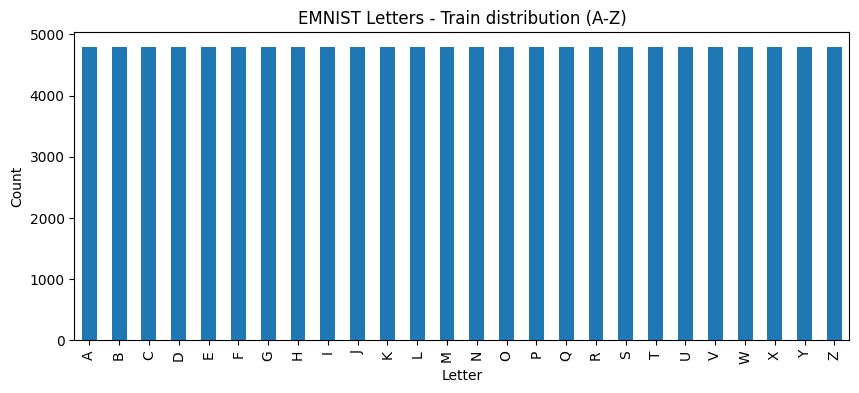

In [7]:
# Map EMNIST 'letters' labels to A-Z characters.
# Note: EMNIST 'letters' labels are 1..26 mapping to 'a'..'z' in many implementations.
# We'll be creating a safe mapping: if labels are 1..26, subtract 1 to get 0..25, then map to A..Z.
def labels_to_chars(labels):
    # convert to 0..25
    unique = np.unique(labels)
    # If labels start at 1, convert to 0-based
    if labels.min() == 1 and labels.max() == 26:
        labels0 = labels - 1
    else:
        labels0 = labels.copy()
    chars = [chr(ord('A') + int(x)) for x in labels0]
    return np.array(chars), labels0

train_chars, train_labels0 = labels_to_chars(train_labels)
test_chars,  test_labels0  = labels_to_chars(test_labels)

# Print counts
train_counts = Counter(train_chars)
test_counts  = Counter(test_chars)
print("Train per-class sample counts (first 10):", list(train_counts.items())[:10])
print("Unique classes in train:", sorted(list(set(train_chars))))

# Plot distribution (train)
plt.figure(figsize=(10,4))
pd.Series([c for c in train_chars]).value_counts().sort_index().plot(kind='bar')
plt.title("EMNIST Letters - Train distribution (A-Z)")
plt.xlabel("Letter")
plt.ylabel("Count")
plt.show()


In [8]:
# Cell 8: Optionally sample 10k-20k images (stratified) to speed up experiments.
SAMPLE_SIZE = 15000   # choose between 10000 and 20000 as recommended
if SAMPLE_SIZE is None or SAMPLE_SIZE >= len(train_imgs_pp):
    X = train_imgs_pp.copy()
    y = train_labels0.copy()
else:
    # Stratified sampling: take roughly (SAMPLE_SIZE / 26) from each class
    df = pd.DataFrame({'idx': np.arange(len(train_imgs_pp)), 'label': train_labels0})
    sampled_idx = []
    per_class = SAMPLE_SIZE // 26
    for lbl in sorted(df['label'].unique()):
        idxs = df[df['label']==lbl]['idx'].values
        chosen = np.random.choice(idxs, size=min(per_class, len(idxs)), replace=False)
        sampled_idx.extend(chosen.tolist())
    # If under SAMPLE_SIZE due to class shortages, fill randomly
    if len(sampled_idx) < SAMPLE_SIZE:
        remaining = list(set(df['idx']) - set(sampled_idx))
        need = SAMPLE_SIZE - len(sampled_idx)
        additional = np.random.choice(remaining, size=need, replace=False).tolist()
        sampled_idx.extend(additional)
    sampled_idx = sorted(sampled_idx)
    X = train_imgs_pp[sampled_idx]
    y = train_labels0[sampled_idx]
    print(f"Sampled {len(X)} images (stratified approx).")

print("X shape:", X.shape, "y shape:", y.shape)


Sampled 15000 images (stratified approx).
X shape: (15000, 28, 28) y shape: (15000,)


In [9]:
# Cell 9: Save preprocessed arrays (optional) and create 80-20 stratified train/test split
np.savez_compressed("emnist_letters_preprocessed_sample.npz", X=X, y=y, test_imgs=test_imgs_pp, test_labels=test_labels0)

# Stratified split into train/val (we'll keep the original test set for final evaluation)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED)
print("After split -> Train:", X_train.shape, "Val:", X_val.shape)


After split -> Train: (12000, 28, 28) Val: (3000, 28, 28)


Saved preprocessed handwritten image -> handwritten_preprocessed.png


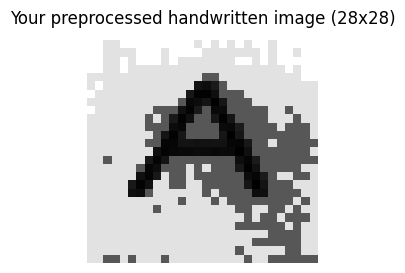

In [12]:
# Cell 10: Load a real handwritten test image (place handwritten.jpg in working dir)
handwritten_path = "Handwritten.png"  # change if your file has a different name/path
if not os.path.exists(handwritten_path):
    print(f"Put your scanned/photographed handwritten letter at: {os.path.abspath(handwritten_path)}")
else:
    hw = cv2.imread(handwritten_path, cv2.IMREAD_COLOR)
    hw_gray = cv2.cvtColor(hw, cv2.COLOR_BGR2GRAY)
    # Resize/crop/pad heuristics to get 28x28 - center and resize
    hw_small = cv2.resize(hw_gray, (28,28), interpolation=cv2.INTER_AREA)
    hw_small = cv2.equalizeHist(hw_small)
    plt.figure(figsize=(3,3))
    plt.imshow(hw_small, cmap='gray')
    plt.title("Your preprocessed handwritten image (28x28)")
    plt.axis('off')
    # Save for later feature extraction / inference
    cv2.imwrite("handwritten_preprocessed.png", hw_small)
    print("Saved preprocessed handwritten image -> handwritten_preprocessed.png")
